# 04 -- Stress Test & Risk Report

Final deliverable notebook -- methodology, results, and limitations for the equity portfolio risk engine. Data is read from Supabase (populated by notebook 01), not pulled fresh from yfinance. Scope note: stress testing here covers the 2008 GFC scenario only (COVID and 2022 rate-hike scenarios, and hypothetical sector shocks, were cut to keep project scope manageable). Executive summary is generated last, from the actual computed results below.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))
sys.path.append(str(project_root / "src"))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

from src.config import SupabaseConfig
from src.risk_engine.var_cvar import compute_all_methods, historical_var_cvar
from src.risk_engine.backtesting import rolling_backtest, kupiec_pof_test
from src.risk_engine.stress_testing import historical_scenario_pnl, stress_vs_var_gap
from src.risk_config import CONFIDENCE_LEVELS, HISTORICAL_SCENARIOS, ASSUMED_PORTFOLIO_VALUE
from src.universe import TICKERS as TICKER_INFO, PORTFOLIO_NAME, PORTFOLIO_DESCRIPTION

In [3]:
load_dotenv()
cfg = SupabaseConfig.from_env()
engine = create_engine(cfg.sqlalchemy_url())

with engine.connect() as conn:
    print(conn.execute(text("SELECT 1")).scalar())

1


## 1. Portfolio Overview

In [4]:
query = """
SELECT
    dd.date_id AS date,
    da.ticker,
    fr.simple_return
FROM fact_returns fr
JOIN dim_date dd ON fr.date_id = dd.date_id
JOIN dim_asset da ON fr.asset_id = da.asset_id
ORDER BY dd.date_id, da.ticker;
"""

returns_long = pd.read_sql(query, engine)
returns_long['date'] = pd.to_datetime(returns_long['date'])
returns_df = returns_long.pivot(index='date', columns='ticker', values='simple_return')

weights_query = """
SELECT
    da.ticker,
    dpw.weight
FROM dim_asset da
JOIN dim_portfolio_weight dpw ON da.asset_id = dpw.asset_id
JOIN dim_portfolio dp ON dpw.portfolio_id = dp.portfolio_id;
"""
weights = pd.read_sql(weights_query, engine).set_index('ticker')['weight']

TICKERS = list(TICKER_INFO.keys())

composition = pd.DataFrame({
    "name": {t: TICKER_INFO[t]["name"] for t in TICKERS},
    "sector": {t: TICKER_INFO[t]["sector"] for t in TICKERS},
    "cap": {t: TICKER_INFO[t]["cap"] for t in TICKERS},
    "weight": weights,
})

print(PORTFOLIO_NAME)
print(PORTFOLIO_DESCRIPTION)
print(f"Date range: {returns_df.index.min()} to {returns_df.index.max()} ({len(returns_df)} trading days)")
composition

Diversified Equity Portfolio
Equal-weight 14-stock portfolio across 9 sectors, large + mid cap, for market risk demonstration.
Date range: 2005-01-04 00:00:00 to 2026-08-14 00:00:00 (5437 trading days)


,name,sector,cap,weight
AAPL,Apple Inc.,Technology,large,0.07143
MSFT,Microsoft Corp.,Technology,large,0.07143
JPM,JPMorgan Chase & Co.,Financials,large,0.07143
GS,Goldman Sachs Group,Financials,large,0.07143
XOM,Exxon Mobil Corp.,Energy,large,0.07143
JNJ,Johnson & Johnson,Healthcare,large,0.07143
MDT,Medtronic plc,Healthcare,large,0.07143
PG,Procter & Gamble,Consumer Staples,large,0.07143
WMT,Walmart Inc.,Consumer Staples,large,0.07143
CAT,Caterpillar Inc.,Industrials,large,0.07143


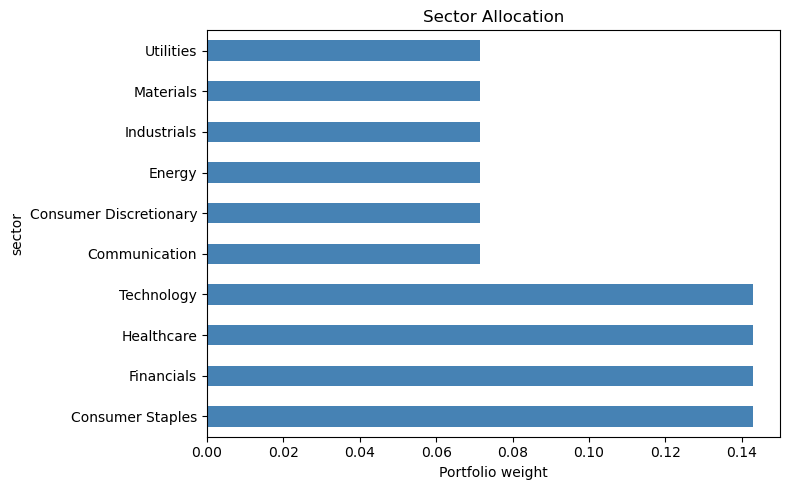

In [5]:
sector_weights = composition.groupby("sector")["weight"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sector_weights.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Portfolio weight")
ax.set_title("Sector Allocation")
plt.tight_layout()
plt.show()

## 2. VaR / CVaR Summary

In [6]:
var_cvar_summary = pd.concat(
    [compute_all_methods(returns_df, weights, confidence=c) for c in CONFIDENCE_LEVELS],
    ignore_index=True,
)
var_cvar_summary

,method,confidence,var_pct,cvar_pct
0,historical,0.95,0.016590,0.026996
1,parametric,0.95,0.018286,0.023086
2,historical,0.99,0.032080,0.047810
3,parametric,0.99,0.026115,0.030008


In [7]:
# Parametric assumes normally-distributed returns; historical uses the empirical
# distribution directly. The gap between them at each confidence level is a
# quick diagnostic for fat tails: if historical VaR/CVaR is meaningfully larger
# than parametric, actual portfolio losses are fatter-tailed than a normal
# distribution would predict -- which is exactly what the 2008 stress result
# below will confirm.
for c in CONFIDENCE_LEVELS:
    row_h = var_cvar_summary[(var_cvar_summary.method == "historical") & (var_cvar_summary.confidence == c)].iloc[0]
    row_p = var_cvar_summary[(var_cvar_summary.method == "parametric") & (var_cvar_summary.confidence == c)].iloc[0]
    diff = row_h.var_pct - row_p.var_pct
    print(f"{int(c*100)}% confidence: historical VaR {row_h.var_pct:.2%} vs parametric VaR {row_p.var_pct:.2%} "
          f"(historical {'higher' if diff > 0 else 'lower'} by {abs(diff):.2%})")

95% confidence: historical VaR 1.66% vs parametric VaR 1.83% (historical lower by 0.17%)
99% confidence: historical VaR 3.21% vs parametric VaR 2.61% (historical higher by 0.60%)


## 3. Backtest Results

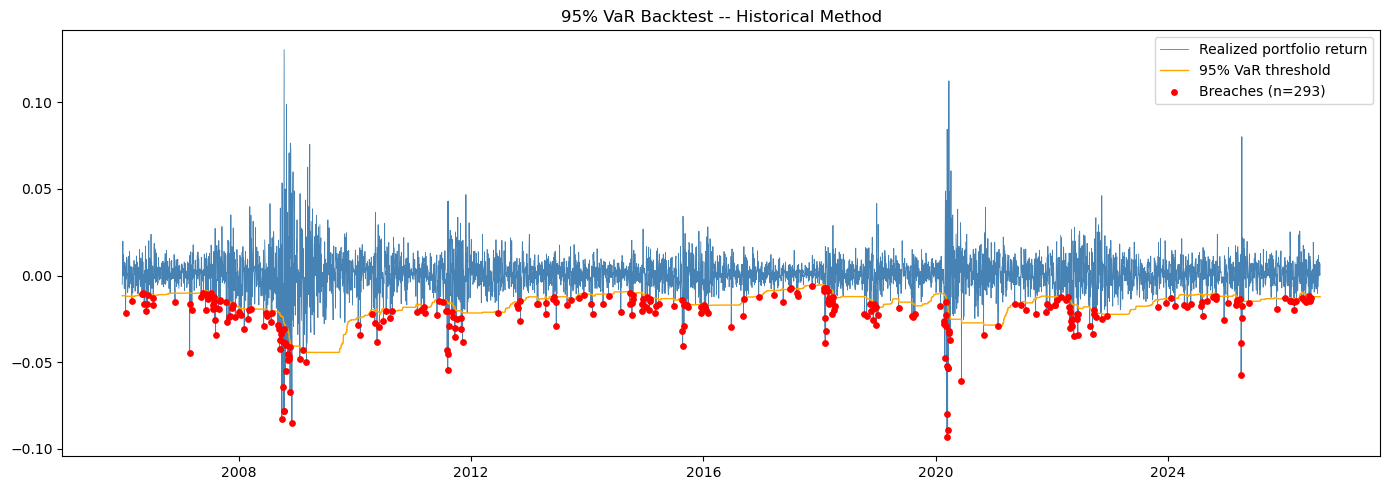

Model REJECTED at 5% significance (p=0.0355). Observed breach rate (5.65%) is significantly HIGHER than expected (5.00%) -- the model is underestimating risk (too many losses exceed predicted VaR).


In [8]:
backtest_confidence = 0.95
backtest_window = 250

backtest_results = rolling_backtest(returns_df, weights, method="historical",
                                     confidence=backtest_confidence, window=backtest_window)
kupiec_result = kupiec_pof_test(backtest_results['breach'], confidence=backtest_confidence)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(backtest_results['date_id'], backtest_results['realized_return_pct'],
        linewidth=0.6, color='steelblue', label='Realized portfolio return')
ax.plot(backtest_results['date_id'], -backtest_results['predicted_var_pct'],
        color='orange', linewidth=1, label=f'{int(backtest_confidence*100)}% VaR threshold')
breach_rows = backtest_results[backtest_results['breach']]
ax.scatter(breach_rows['date_id'], breach_rows['realized_return_pct'],
           color='red', s=15, zorder=5, label=f"Breaches (n={len(breach_rows)})")
ax.set_title(f'{int(backtest_confidence*100)}% VaR Backtest -- Historical Method')
ax.legend()
plt.tight_layout()
plt.show()

print(kupiec_result['verdict'])

## 4. Stress Test Results -- 2008 GFC

In [9]:
start_2008, end_2008 = HISTORICAL_SCENARIOS["2008 GFC (Lehman collapse)"]
gfc_result = historical_scenario_pnl(returns_df, weights, start_2008, end_2008)
gfc_result

{'start_date': '2008-09-01',
 'end_date': '2008-11-30',
 'cumulative_pnl_pct': np.float64(-0.24247519446436328),
 'n_trading_days': 63,
 'worst_single_day_pct': -0.08287244312999997}

In [10]:
# Headline: how much bigger was the actual 2008 loss than what 95% historical
# VaR (estimated over the FULL sample) would have predicted for a single day?
full_sample_var, full_sample_cvar = historical_var_cvar(returns_df, weights, confidence=backtest_confidence)

gap_result = stress_vs_var_gap(gfc_result['cumulative_pnl_pct'], full_sample_var)

print(f"2008 GFC window ({gfc_result['start_date']} to {gfc_result['end_date']}, "
      f"{gfc_result['n_trading_days']} trading days):")
print(f"  Cumulative portfolio P&L: {gfc_result['cumulative_pnl_pct']:.2%}")
print(f"  Worst single day: {gfc_result['worst_single_day_pct']:.2%}")
print()
print(f"Full-sample 95% single-day historical VaR: {full_sample_var:.2%}")
print(f"Stress loss is {gap_result['gap_multiple']:.1f}x the single-day VaR estimate "
      f"(gap of {gap_result['gap']:.2%})")

2008 GFC window (2008-09-01 to 2008-11-30, 63 trading days):
  Cumulative portfolio P&L: -24.25%
  Worst single day: -8.29%

Full-sample 95% single-day historical VaR: 1.66%
Stress loss is 14.6x the single-day VaR estimate (gap of 22.59%)


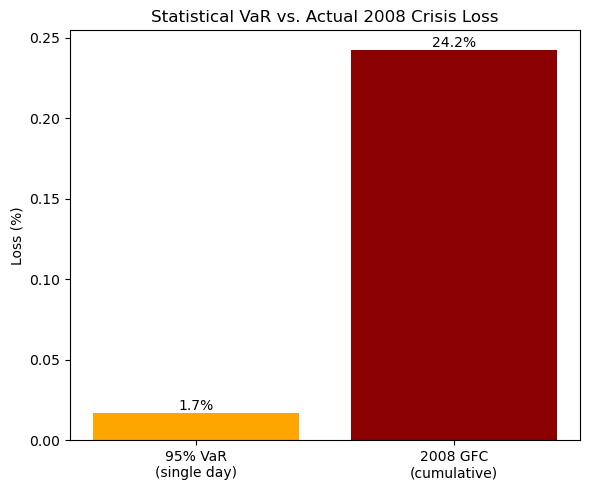

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    ["95% VaR\n(single day)", "2008 GFC\n(cumulative)"],
    [full_sample_var, abs(gfc_result['cumulative_pnl_pct'])],
    color=["orange", "darkred"],
)
ax.set_ylabel("Loss (%)")
ax.set_title("Statistical VaR vs. Actual 2008 Crisis Loss")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.1%}",
            ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Push 2008 GFC stress test result to Supabase (`fact_stress_test`)

In [12]:
portfolio_id = pd.read_sql(
    "SELECT portfolio_id FROM dim_portfolio WHERE portfolio_name = %(name)s",
    engine, params={"name": PORTFOLIO_NAME}
)["portfolio_id"].iloc[0]

scenario_name = "2008 GFC (Lehman collapse)"

stress_row = pd.DataFrame([{
    "portfolio_id": int(portfolio_id),
    "scenario_name": scenario_name,
    "scenario_type": "historical",
    "start_date": gfc_result["start_date"],
    "end_date": gfc_result["end_date"],
    "portfolio_pnl_pct": gfc_result["cumulative_pnl_pct"],
    "portfolio_pnl_value": gfc_result["cumulative_pnl_pct"] * ASSUMED_PORTFOLIO_VALUE,
}])

# Same append-only pattern as notebook 01's fact_price/fact_returns inserts.
# fact_stress_test only has a serial PK (no natural unique key), so -- as
# with 01's tables -- rerunning this cell will insert a new row each time
# rather than updating in place.
stress_row.to_sql("fact_stress_test", engine, if_exists="append", index=False)

pd.read_sql(
    "SELECT * FROM fact_stress_test WHERE portfolio_id = %(pid)s AND scenario_name = %(name)s ORDER BY computed_at DESC",
    engine, params={"pid": int(portfolio_id), "name": scenario_name}
)

,scenario_id,portfolio_id,scenario_name,scenario_type,start_date,end_date,portfolio_pnl_pct,portfolio_pnl_value,computed_at
0,1,1,2008 GFC (Lehman collapse),historical,2008-09-01,2008-11-30,-0.242475,-2424751.94,2026-08-16 15:54:22.684753+00:00


## 5. Limitations & Assumptions

- **Normal distribution assumption in parametric VaR** understates tail risk -- real returns are fat-tailed, which is exactly what section 2's historical-vs-parametric gap and section 4's stress result both show.
- **Historical VaR assumes the future resembles the lookback window.** A 250-day trailing window that excludes a crisis will underpredict risk going into one; a window that includes a crisis will overpredict risk for a while after.
- **This project only stress-tests 2008.** COVID-19 (Feb-Mar 2020) and the 2022 rate-hike selloff were cut for scope; each stresses the portfolio differently (2008 is slow-moving and correlation-driven, COVID is a fast liquidity shock), so the single 2008 result should not be read as a complete tail-risk picture.
- **No hypothetical/sector-shock scenarios were modeled** -- only the historical 2008 replay. A more complete risk framework would also test shocks that haven't happened historically (e.g. a sector-specific crash).
- **Equal-weight portfolio is a simplification** versus a real risk-managed book, which would size positions by risk contribution, not equal dollar weight.
- **250-day rolling window is a standard but arbitrary choice** -- shorter windows react faster to regime changes but are noisier; this trade-off isn't tested here.

## Executive Summary

In [13]:
# Auto-generated from the results computed above -- not hand-written, so it
# stays accurate if you rerun with different data.
var_95_hist = var_cvar_summary[(var_cvar_summary.method == "historical") & (var_cvar_summary.confidence == 0.95)].iloc[0]

summary = f"""
{PORTFOLIO_NAME} ({len(TICKERS)} stocks, {composition['sector'].nunique()} sectors, equal-weighted).

At 95% confidence, historical-simulation VaR is {var_95_hist.var_pct:.2%} of portfolio value per day
(CVaR {var_95_hist.cvar_pct:.2%}). The Kupiec POF backtest over the full sample {"does not reject" if not kupiec_result['reject_h0_at_5pct'] else "rejects"}
the model at 5% significance ({kupiec_result['n_breaches']} breaches in {kupiec_result['n_observations']} observations,
vs {kupiec_result['expected_breach_rate']:.1%} expected).

The 2008 GFC stress scenario produced a cumulative portfolio loss of {gfc_result['cumulative_pnl_pct']:.2%} over
{gfc_result['n_trading_days']} trading days -- {gap_result['gap_multiple']:.1f}x the single-day 95% VaR estimate,
underscoring that VaR characterizes a typical bad day, not a sustained crisis.
"""
print(summary)


Diversified Equity Portfolio (14 stocks, 10 sectors, equal-weighted).

At 95% confidence, historical-simulation VaR is 1.66% of portfolio value per day
(CVaR 2.70%). The Kupiec POF backtest over the full sample rejects
the model at 5% significance (293 breaches in 5187 observations,
vs 5.0% expected).

The 2008 GFC stress scenario produced a cumulative portfolio loss of -24.25% over
63 trading days -- 14.6x the single-day 95% VaR estimate,
underscoring that VaR characterizes a typical bad day, not a sustained crisis.

